# GNN Training

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from gnn_project.config import Config
from gnn_project.training.train_utils import train_or_load_model, load_data

## GNN Model

In [2]:
config = Config(
    ml_data_dir='/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data',
    experiment_name='gnn_v1',
    sim_start=0,
    sim_end=2*60*60,
    load_saved_model=False,
    overwrite_data=True,
    log_level='DEBUG',
)

In [3]:
import logging
logging.basicConfig(level=config.log_level)

In [4]:
data, masks = load_data(config)

DEBUG:gnn_project.dataloaders.gnn_dataloader:Total number of scenarios: 3
DEBUG:gnn_project.dataloaders.gnn_dataloader:Train size: 1, Val size: 1, Test size: 1
Normalizing scenarios: 100%|██████████| 3/3 [00:22<00:00,  7.60s/it]
DEBUG:gnn_project.dataloaders.gnn_dataloader:Scenario split: Train=1, Val=1, Test=1 scenarios
DEBUG:gnn_project.dataloaders.gnn_dataloader:Timestep split: Train=7171, Val=7171, Test=7171 timesteps


In [5]:
model, trainer = train_or_load_model(config, data, masks)

DEBUG:gnn_project.training.trainer:Filtered 6931 empty graphs from dataset
DEBUG:gnn_project.training.trainer:Filtered 6933 empty graphs from dataset
DEBUG:gnn_project.training.trainer:Filtered 6931 empty graphs from dataset
[Batch   0] Loss: 0.5313 | Class dist - Target: [2966, 588] Pred: [2145, 1409]
[Batch  10] Loss: 0.3810 | Class dist - Target: [4482, 710] Pred: [3472, 1720]
[Batch  20] Loss: 0.4001 | Class dist - Target: [1552, 392] Pred: [1188, 756]
INFO:gnn_project.training.trainer:
INFO:gnn_project.training.trainer:Epoch 1/500
INFO:gnn_project.training.trainer:--------------------------------------------------------------------------------
INFO:gnn_project.training.trainer:Metric          Training        Validation     
INFO:gnn_project.training.trainer:--------------------------------------------------------------------------------
INFO:gnn_project.training.trainer:Loss            0.4046          -              
INFO:gnn_project.training.trainer:Accuracy        0.6406        

## Visualization

In [6]:
logging.basicConfig(level='INFO')

In [7]:
from gnn_project.analysis.plots import visualize_graph
from gnn_project.training.train_utils import get_edge_predictions

graph_idx = 12  # Index of the graph to visualize
predictions = get_edge_predictions(data[graph_idx], model, device='cpu')
visualize_graph(data, graph_idx=graph_idx, predictions=predictions, device=config.device, only_new_requests=True);

DEBUG:matplotlib:matplotlib data path: /Users/hoda_hamdy/Documents/Tools/Anaconda/envs/FleetPy/lib/python3.10/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/hoda_hamdy/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/hoda_hamdy/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/hoda_hamdy/.matplotlib/fontlist-v390.json


No new requests to visualize in this graph


DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=14.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/hoda_hamdy/Documents/Tools/Anaconda/envs/FleetPy/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/cmss10.ttf', name='cmss10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/hoda_hamdy/Documents/Tools/Anaconda/envs/FleetPy/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXGeneral.ttf', name='STIXGeneral', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/hod

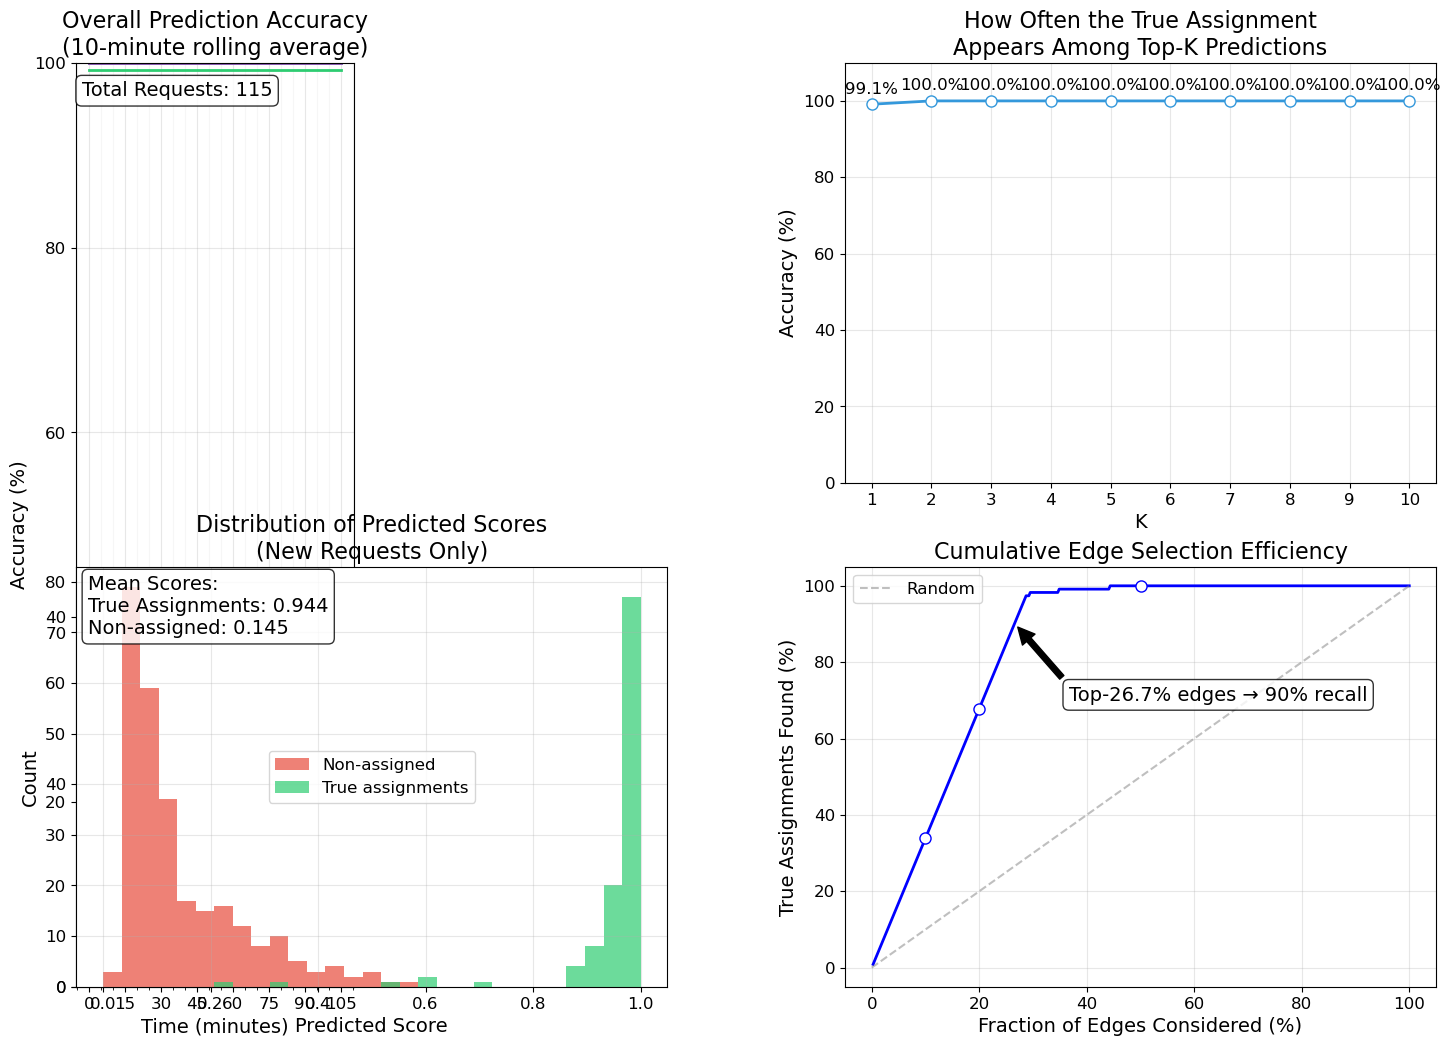

In [8]:
# Analyze model performance over a range of graphs
from gnn_project.analysis.plots import analyze_model_performance
import matplotlib.pyplot as plt
start_idx = 480  # Starting graph index
num_graphs = 240  # Number of graphs to analyze

# TODO split to separate plots
predictions = [get_edge_predictions(data[i], model, device='cpu') for i in range(start_idx, start_idx + num_graphs)]
fig = analyze_model_performance(data, start_idx, num_graphs, predictions, config.device)
if fig:
    plt.show()

In [3]:
import pandas as pd

pd.read_parquet('/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/processed/test_manhattan_scenario_1/request_features.parquet').columns

Index(['clustering_coeff', 'd_lat', 'd_lon', 'demand_supply_ratio',
       'direct_td', 'direct_tt', 'id', 'in_degree_from_requests',
       'in_degree_from_vehicles', 'in_degree_total', 'locked',
       'manhattan_distance', 'max_trip_time', 'nearby_requests',
       'nearby_vehicles', 'nx_combined_betweenness_centrality',
       'nx_combined_closeness_centrality', 'nx_combined_degree_centrality',
       'nx_combined_pagerank', 'nx_rr_betweenness_centrality',
       'nx_rr_closeness_centrality', 'nx_rr_degree_centrality',
       'nx_rr_pagerank', 'o_lat', 'o_lon', 'origin_dest_bearing',
       'out_degree_to_requests', 'out_degree_to_vehicles', 'out_degree_total',
       'request_age', 'request_vehicle_in_ratio', 'request_vehicle_out_ratio',
       'route_directness', 'rq_time', 'status', 'time_until_earliest',
       'time_until_latest', 'time_window_urgency', 'time_window_width',
       'timestep', 'tw_pe', 'tw_pl'],
      dtype='object')

In [4]:
pd.read_parquet('/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/processed/test_manhattan_scenario_1/vehicle_features.parquet').columns

Index(['clustering_coeff', 'id', 'in_degree', 'in_degree_from_requests', 'lat',
       'lon', 'nx_combined_betweenness_centrality',
       'nx_combined_closeness_centrality', 'nx_combined_degree_centrality',
       'nx_combined_pagerank', 'nx_vr_betweenness_centrality',
       'nx_vr_closeness_centrality', 'nx_vr_degree_centrality',
       'nx_vr_pagerank', 'out_degree', 'out_degree_to_requests', 'soc',
       'status', 'timestep', 'total_request_connections', 'type'],
      dtype='object')